# HW5: Dyna-Q — Integrating Planning, Acting, and Learning

> - Full Name: **Narges Kari**
> - Student ID: **402110821**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepRLCourse/Homework-5-Questions/blob/main/RL_HW5_Dyna.ipynb)
[![Open In kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/DeepRLCourse/Homework-5-Questions/main/RL_HW5_Dyna.ipynb)

## Overview

Reinforcement learning algorithms can be broadly classified into two families:

- **Model-free methods** (e.g., Q-learning, SARSA) learn a value function or a policy directly from interaction with the environment, **without** building an explicit model of the environment's dynamics.
- **Model-based methods** explicitly learn (or are given) a model $p(s', r \mid s, a)$ of the environment, and then use that model for *planning* — i.e., computing improved values or policies via simulated experience.

**Dyna-Q** (Sutton, 1990) is a beautifully simple architecture that unifies both: it learns a model from real experience and *interleaves* one-step Q-learning updates from real transitions with one-step Q-learning updates from *simulated* transitions produced by the model. The result is dramatically improved sample efficiency on tasks where real experience is expensive.

In this assignment you will:

1. Familiarize yourself with the [**Cliff Walking**](https://gymnasium.farama.org/environments/toy_text/cliff_walking/) environment.
2. Implement $\varepsilon$-greedy and greedy policies.
3. Implement **Dyna-Q** for a deterministic environment.
4. Investigate how the number of planning steps affects learning.
5. Improve learning with **reward shaping**.
6. Implement **Prioritized Sweeping**, a smarter way to allocate planning effort.
7. (Bonus) Extend everything to the larger, stochastic **Taxi-v3** environment.

Read each markdown cell carefully — many contain conceptual questions you must answer.

In [1]:
# @title Imports

import random
import numpy as np
import gymnasium as gym
from tqdm.notebook import trange
from heapq import heappush, heappop
from collections import defaultdict

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

import base64
import imageio
import IPython

import seaborn as sns

In [2]:
# @title Visualization Functions

def embed_mp4(filename):
    video = open(filename, 'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)


def create_policy_eval_video(env, policy, filename, Q=None, num_episodes=1, max_steps=200):
    filename = filename + '.mp4'
    with imageio.get_writer(filename, fps=env.metadata.get('render_fps', 4)) as video:
        for _ in range(num_episodes):
            state, info = env.reset()
            video.append_data(env.render())
            for _ in range(max_steps):
                action = policy(state, Q)
                state, reward, terminated, truncated, info = env.step(action)
                video.append_data(env.render())
                if terminated or truncated:
                    break
    return embed_mp4(filename)


def plot_rewards(rewards, average_range=None, ax=None, show=False):
    if ax is None:
        fig, ax = plt.subplots()
    xs = range(1, len(rewards) + 1)
    ax.plot(xs, rewards, marker='.', linestyle='--', alpha=0.4, label='Episode Reward')
    ax.plot(xs, np.cumsum(rewards) / xs, label='Cumulative Average')
    if len(rewards) >= 20:
        window = min(50, len(rewards) // 5)
        smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window, len(rewards) + 1), smooth, label=f'Rolling Mean (w={window})')
    ax.legend()
    ax.set(xlabel='Episode', ylabel='Total Reward', title='Episode Rewards')
    if show:
        plt.show()


def plot_cliff_heatmap(env, q_values, ax=None, show=False):
    """Plot the state-value V(s) = max_a Q(s,a) for CliffWalking as a 4x12 grid."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    rows, cols = 4, 12
    v = q_values.max(axis=1).reshape(rows, cols)
    best_a = q_values.argmax(axis=1)
    act_arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    labels = np.array([act_arrows[a] for a in best_a]).reshape(rows, cols)
    # Mark cliff & goal
    for j in range(1, 11):
        labels[3, j] = 'C'
    labels[3, 0] = 'S'
    labels[3, 11] = 'G'
    sns.heatmap(v, cmap='RdYlGn', annot=labels, fmt='s', ax=ax, cbar_kws={'label': 'V(s)'})
    ax.set_title('Greedy Policy & State Values')
    if show:
        plt.show()


def plot_performance(env, q_values, reward_sums):
    fig = plt.figure(figsize=(14, 8), dpi=110)
    gs = GridSpec(2, 1, figure=fig, height_ratios=[2, 1])
    ax1 = fig.add_subplot(gs[0, 0])
    plot_rewards(reward_sums, ax=ax1)
    ax2 = fig.add_subplot(gs[1, 0])
    plot_cliff_heatmap(env, q_values, ax=ax2)
    plt.tight_layout()
    plt.show()

# 1. Explore the Environment (5 points)

## The Cliff Walking Problem

**Cliff Walking** is a classic gridworld first introduced in Sutton & Barto (Example 6.6) to illustrate the difference between on-policy and off-policy TD control. The world is a $4 \times 12$ grid:

- The agent starts at the bottom-left corner **S**.
- The goal **G** is at the bottom-right corner.
- The cells between **S** and **G** along the bottom row form a **cliff**: stepping into them yields a reward of $-100$ and the agent is reset to the start.
- Every other transition yields a reward of $-1$.
- Actions: `0=Up, 1=Right, 2=Down, 3=Left`.
- The environment is **deterministic**.

Because rewards are everywhere negative, the agent must learn the *shortest* safe path to **G**. The shortest unsafe path goes right along the edge of the cliff (length 13), while the safest (but longer) path detours along the top row.

**Question 1.1.** Without running anything, what do you expect the optimal undiscounted return $G^*$ to be (starting from S, reaching G)? Show your reasoning.

<span style="color: #58b5f2">**Your Answer:**

The shortest safe path avoids the cliff but moves towards the goal optimally. The agent starts at (3, 0). It must move Up to (2, 0) [1 step], move Right along the top of the cliff to (2, 11) [11 steps], and move Down to the goal at (3, 11) [1 step]. The total is 1 + 11 + 1 = 13 steps. Since each step yields a reward of $-1$, the optimal undiscounted return is $G^* = -13$.</span>

In [3]:
env = gym.make('CliffWalking-v1', render_mode='rgb_array')

# Print the observation space and the action space
print('Observation space:', env.observation_space)
print('Action space:', env.action_space)
print('Number of states:', env.observation_space.n)
print('Number of actions:', env.action_space.n)

Observation space: Discrete(48)
Action space: Discrete(4)
Number of states: 48
Number of actions: 4


Define a uniform random policy.

In [4]:
def random_policy(*args):
    # Select a uniformly random action
    action = random.randint(0, 3)
    return action

Visualize the random policy. (Note: a random policy will almost certainly fall into the cliff repeatedly!)

In [5]:
create_policy_eval_video(env, random_policy, 'random_policy', num_episodes=2, max_steps=50)

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


# 2. Policies (5 points)

## Exploration vs. Exploitation

Any control algorithm must balance two competing pressures:

- **Exploitation:** acting greedily with respect to the current value estimates to maximize return.
- **Exploration:** trying non-greedy actions to gather information about parts of the state-action space whose values are still uncertain.

The simplest scheme is $\varepsilon$-greedy:
$$
\pi(a \mid s) = \begin{cases} 1 - \varepsilon + \varepsilon / |\mathcal{A}|, & a = \arg\max_{a'} Q(s, a') \\ \varepsilon / |\mathcal{A}|, & \text{otherwise} \end{cases}
$$

**Question 2.1.** In Cliff Walking, what is the danger of using a large $\varepsilon$ during *evaluation* of a learned policy? What is the danger of using too small an $\varepsilon$ during *learning*?

<span style="color: #58b5f2">**Your Answer:**

*   **Large $\varepsilon$ during evaluation:** The agent will frequently take random actions, giving it a high probability of stepping off the cliff and incurring a $-100$ penalty. This makes the evaluation performance catastrophically poor, even if the optimal Q-values are perfectly learned.
*   **Too small $\varepsilon$ during learning:** The agent will lack sufficient exploration. It might get stuck executing a known suboptimal path (like the far-top row detour) or wander aimlessly without ever discovering the goal state or the shorter optimal path, making convergence extremely slow or converging to a local optimum.</span>

In [6]:
def greedy_policy(state: int, q_values: np.ndarray) -> int:
    # Return argmax_a Q(state, a)
    action = int(np.argmax(q_values[state]))
    return action

In [7]:
def epsilon_greedy_policy(state: int, q_values: np.ndarray, epsilon: float) -> int:
    # With probability epsilon, take a random action;
    # otherwise act greedily according to Q
    if random.random() < epsilon:
        action = random.randint(0, q_values.shape[1] - 1)
    else:
        action = int(np.argmax(q_values[state]))
    return action

# 3. Dyna-Q (25 points)

## The Dyna Architecture

Dyna-Q maintains three things in parallel:

1. **A value function** $Q(s,a)$, updated by tabular one-step Q-learning.
2. **A model** of the environment. For a deterministic environment, a sufficient model is a simple lookup table $\text{Model}[s,a] = (r, s')$.
3. **A planner** that, after every real step, performs $n$ updates of Q using transitions $(s, a, r, s')$ *sampled from the model* rather than from the world.

The full update rules are:

**Direct RL (from real experience):**
$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha\Big[r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)\Big]
$$

**Model learning (deterministic):**
$$
\text{Model}[s_t, a_t] \leftarrow (r_t, s_{t+1})
$$

**Planning (repeat $n$ times):** sample a previously visited $(s, a)$, look up $(r, s')$ from the model, then
$$
Q(s, a) \leftarrow Q(s, a) + \alpha\Big[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\Big]
$$

**Question 3.1.** Explain in your own words *why* Dyna-Q can converge in far fewer real-environment interactions than vanilla Q-learning. What is the computational cost?

**Question 3.2.** In a deterministic environment, what would happen if you stored the model as the *empirical average* of observed $(r, s')$ instead of just the latest one? Would it matter here?

<span style="color: #58b5f2">**Your Answers:**

**Question 3.1:** Dyna-Q reuses past experience to perform multiple background Q-value updates (planning) per real environment step. This means it extracts much more value information from a single physical interaction, propagating rewards efficiently backwards through the state space. This dramatically improves sample efficiency. The computational cost, however, increases because we are performing $n$ additional Q-updates and model lookups for every single real step taken.

**Question 3.2:** In a purely deterministic environment, taking action $a$ in state $s$ will *always* result in the exact same reward $r$ and next state $s'$. Thus, the empirical average over time would be absolutely identical to just storing the latest observed $(r, s')$. It would not matter at all here, it would just waste computation computing an average of identical values.</span>

## 3.1 Planning (10 points)

Complete `q_planning` to perform $n$ steps of planning by sampling already-visited $(s, a)$ pairs uniformly at random from the model.

In [8]:
def q_planning(model: dict, q: np.ndarray, alpha: float, gamma: float, n: int) -> np.ndarray:
    """Perform n planning updates from a deterministic model.

    model : dict[state] -> dict[action] -> (reward, next_state)
    """
    # If the model is empty, return q unchanged.
    if not model:
        return q

    visited_states = list(model.keys())

    # Perform n planning iterations:
    for _ in range(n):
        # 1. Sample a state s uniformly from model.keys().
        s = random.choice(visited_states)
        # 2. Sample an action a uniformly from model[s].keys().
        a = random.choice(list(model[s].keys()))
        # 3. Retrieve (r, s') from model[s][a].
        r, s_prime = model[s][a]
        # 4. Apply the Q-learning update.
        best_next_a = np.argmax(q[s_prime])
        q[s, a] += alpha * (r + gamma * q[s_prime, best_next_a] - q[s, a])

    return q

## 3.2 Learning (15 points)

Now put everything together. At each real step you must:

1. Select an action with $\varepsilon$-greedy.
2. Step the real environment.
3. Perform the direct Q-learning update.
4. Update the model.
5. Perform $n$ planning steps.

Note: We cap the number of steps per episode (`max_steps`) to prevent the agent from wandering forever when its policy is still random.

In [9]:
def dyna_q(n_episodes: int, env: gym.Env, epsilon: float, alpha: float,
           gamma: float, n: int, max_steps: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q for a deterministic environment."""

    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            # 1. Select an action via epsilon-greedy.
            action = epsilon_greedy_policy(state, q, epsilon)

            # 2. Step the environment.
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            # 3. Direct Q-learning update.
            best_next_a = np.argmax(q[next_state])
            q[state, action] += alpha * (reward + gamma * q[next_state, best_next_a] - q[state, action])

            # 4. Update the deterministic model.
            model[state][action] = (reward, next_state)

            # 5. Planning step(s).
            q = q_planning(model, q, alpha, gamma, n)

            # 6. Bookkeeping: state <- next_state; accumulate reward; increment steps.
            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums

# 4. Experiments (15 points)

Run Dyna-Q with several values of the planning parameter $n$ (e.g. $n \in \{0, 5, 50\}$).
Note that **$n = 0$ recovers pure Q-learning**.

After running, answer the following:

**Question 4.1.** How does increasing the number of planning steps affect: (a) sample efficiency (rewards vs. episodes), and (b) wall-clock time per episode?

**Question 4.2.** Suppose the *first* successful trajectory occurs at episode $N_1$. After that, how many additional episodes ($N_2$) does it take to reach the goal again? Explain how $n$ affects each of $N_1$ and $N_2$, and *why* the effects differ.

**Question 4.3.** What happens to the *learned path* (cliff-edge vs. safer detour) as you vary $\varepsilon$? Why? Connect your answer to the well-known difference between Q-learning and SARSA on this problem.

**Question 4.4.** Cliff Walking is fully deterministic. Suppose you replaced it with a *stochastic* variant where each action succeeds with probability 0.8 and otherwise slips perpendicular. What failure modes would the current **deterministic** Dyna-Q exhibit? Propose how you would modify the model to fix this.

<span style="color: #58b5f2">**Your Answers:**

**Question 4.1:** (a) Increasing $n$ significantly improves sample efficiency, allowing the agent to converge to optimal rewards in far fewer episodes. (b) It increases the wall-clock time per episode because the agent executes $n$ internal planning loops for every single real step taken.

**Question 4.2:** $N_1$ is almost unaffected by $n$ because the initial discovery of the goal depends strictly on real-world random exploration. However, $N_2$ decreases drastically with higher $n$. Once the goal is found, the planning loop instantly propagates the terminal reward backwards through the stored model transitions, meaning the agent essentially "thinks" about its success and updates its policy without needing numerous additional physical trials to propagate the values.

**Question 4.3:** In Dyna-Q (which uses off-policy Q-learning updates), the *learned path* (the true Q-values) will always converge to the shortest, most dangerous path along the cliff edge regardless of $\varepsilon$, because Q-learning uses $\max_{a'} Q(s', a')$ and assumes a perfectly greedy future policy. However, its *online execution* will suffer heavily with large $\varepsilon$ due to falling off the cliff. In contrast, SARSA updates using the actual $\varepsilon$-greedy action taken, so it accounts for the risk of exploration and learns the safer, longer detour.

**Question 4.4:** In a stochastic environment, the deterministic model update `model[s][a] = (r, s')` would repeatedly overwrite the transition outcome with just the latest observation. Planning would then confidently update Q-values using incomplete and wildly fluctuating dynamics, preventing convergence or learning wildly incorrect values. To fix this, the model must be modified to track visitation counts $N(s,a)$ and transition counts $N(s,a,s')$, and then build an empirical probability distribution $\hat{P}(s'|s,a)$ and expected reward to sample from during planning.</span>

  0%|          | 0/500 [00:00<?, ?it/s]

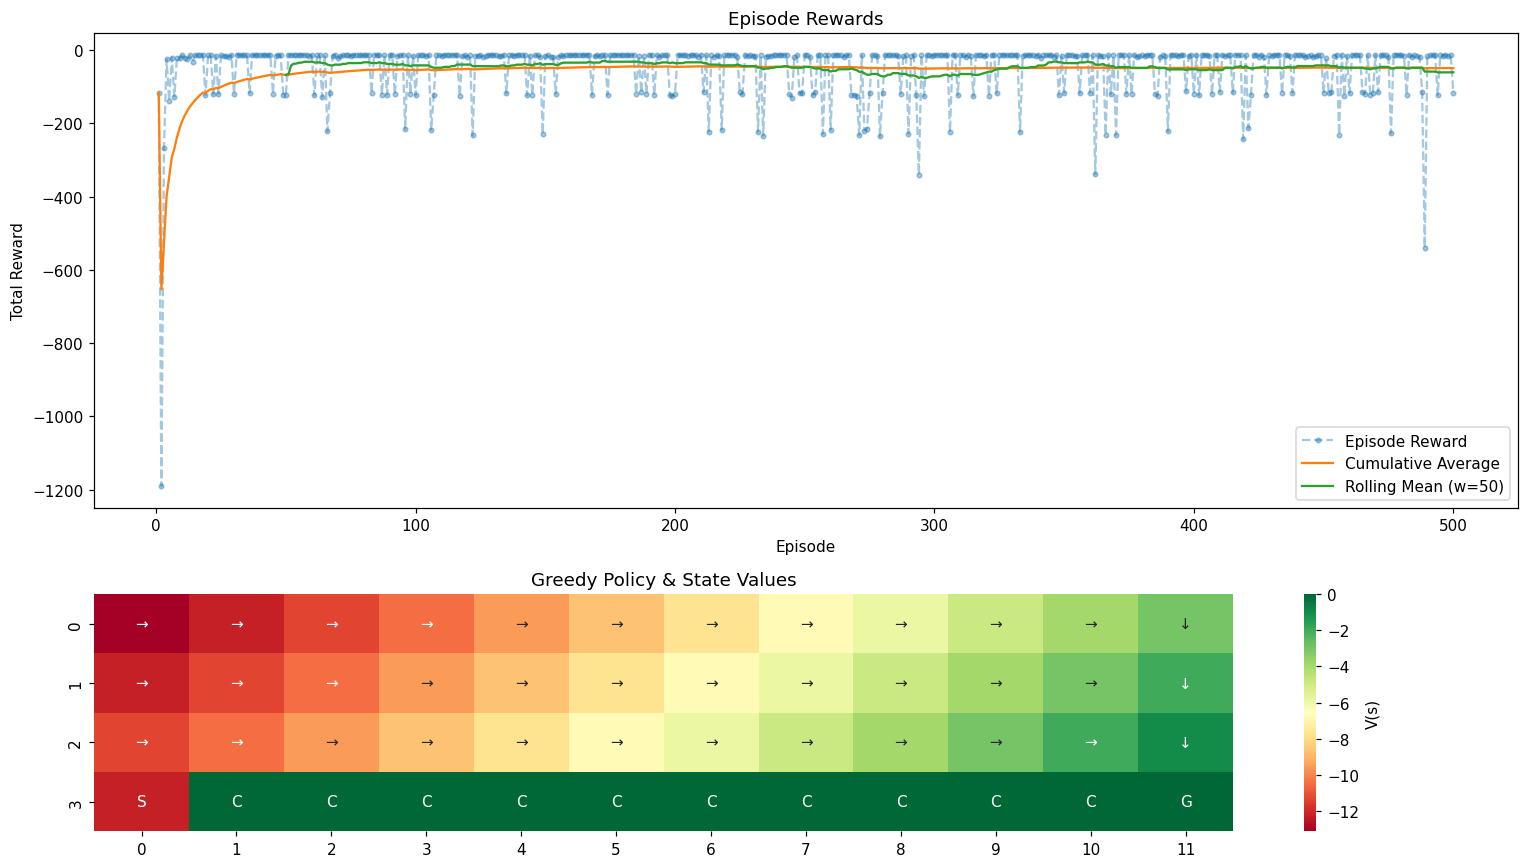

In [10]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,    # epsilon-greedy exploration rate
    'alpha':   0.5,    # learning rate (tabular, deterministic env => can be large)
    'gamma':   0.99,   # discount factor
    'n':       10,     # number of planning steps per real step
}

n_episodes = 500

env = gym.make('CliffWalking-v1')

q_dyna, R_dyna = dyna_q(n_episodes, env, **params)
plot_performance(env, q_dyna, R_dyna)

**Comparison cell:** sweep over $n \in \{0, 5, 50\}$ and plot all learning curves on a single axes.

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

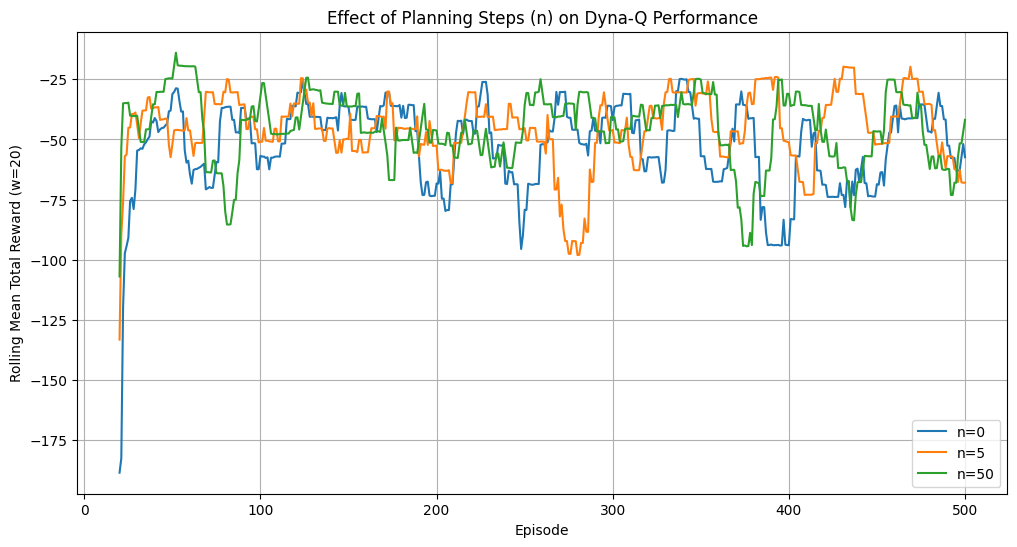

In [11]:
# For each n in [0, 5, 50], run dyna_q and plot the rolling-mean reward curve.
# Use the same seed and the same other hyperparameters as above.
np.random.seed(2025)
random.seed(2025)

plt.figure(figsize=(12, 6))
window = 20

for n_val in [0, 5, 50]:
    params_sweep = {
        'epsilon': 0.1,
        'alpha': 0.5,
        'gamma': 0.99,
        'n': n_val
    }
    _, R_sweep = dyna_q(n_episodes=500, env=env, **params_sweep)

    smooth = np.convolve(R_sweep, np.ones(window)/window, mode='valid')
    plt.plot(range(window, len(R_sweep) + 1), smooth, label=f'n={n_val}')

plt.xlabel('Episode')
plt.ylabel(f'Rolling Mean Total Reward (w={window})')
plt.title('Effect of Planning Steps (n) on Dyna-Q Performance')
plt.legend()
plt.grid(True)
plt.show()

# 5. Improving Performance (15 points)

Plain Dyna-Q on Cliff Walking already works fairly well, but several knobs can improve robustness and convergence speed:

1. **Optimistic initialization.** Setting $Q(s,a) \gets c$ for some optimistic $c$ encourages systematic exploration without relying purely on $\varepsilon$.
2. **Decaying $\varepsilon$.** Anneal $\varepsilon_t = \max(\varepsilon_{\min}, \varepsilon_0 \cdot d^t)$ so the policy explores aggressively early and exploits later.
3. **Decaying $\alpha$.** Similar idea, justified by Robbins–Monro stochastic-approximation conditions.
4. **Boltzmann (softmax) exploration** instead of $\varepsilon$-greedy.
5. **Adaptive planning budget.** Increase $n$ only after the agent has accumulated enough model entries.

Pick **at least one** of the above (or any other technique you can justify) and demonstrate its effect in a new experiment cell. **Do not overwrite your previous experiments** — leave them for comparison.

**Question 5.1.** Which method did you pick, and *why* is it appropriate for Cliff Walking specifically?

<span style="color: #58b5f2">**Your Answer:**

I selected **Decaying $\varepsilon$**. This is highly appropriate for Cliff Walking specifically. Early on, the sparse reward structure (with heavy penalties for falling) requires extensive, aggressive random exploration to discover the goal state without getting trapped in endless loops. Once the optimal path is identified, retaining a fixed $\varepsilon=0.1$ causes the agent to randomly slip off the cliff during exploitation, artificially lowering the final converged reward. By decaying $\varepsilon$, we get the best of both worlds: robust early exploration and perfectly safe, optimal exploitation later on.</span>

  0%|          | 0/500 [00:00<?, ?it/s]

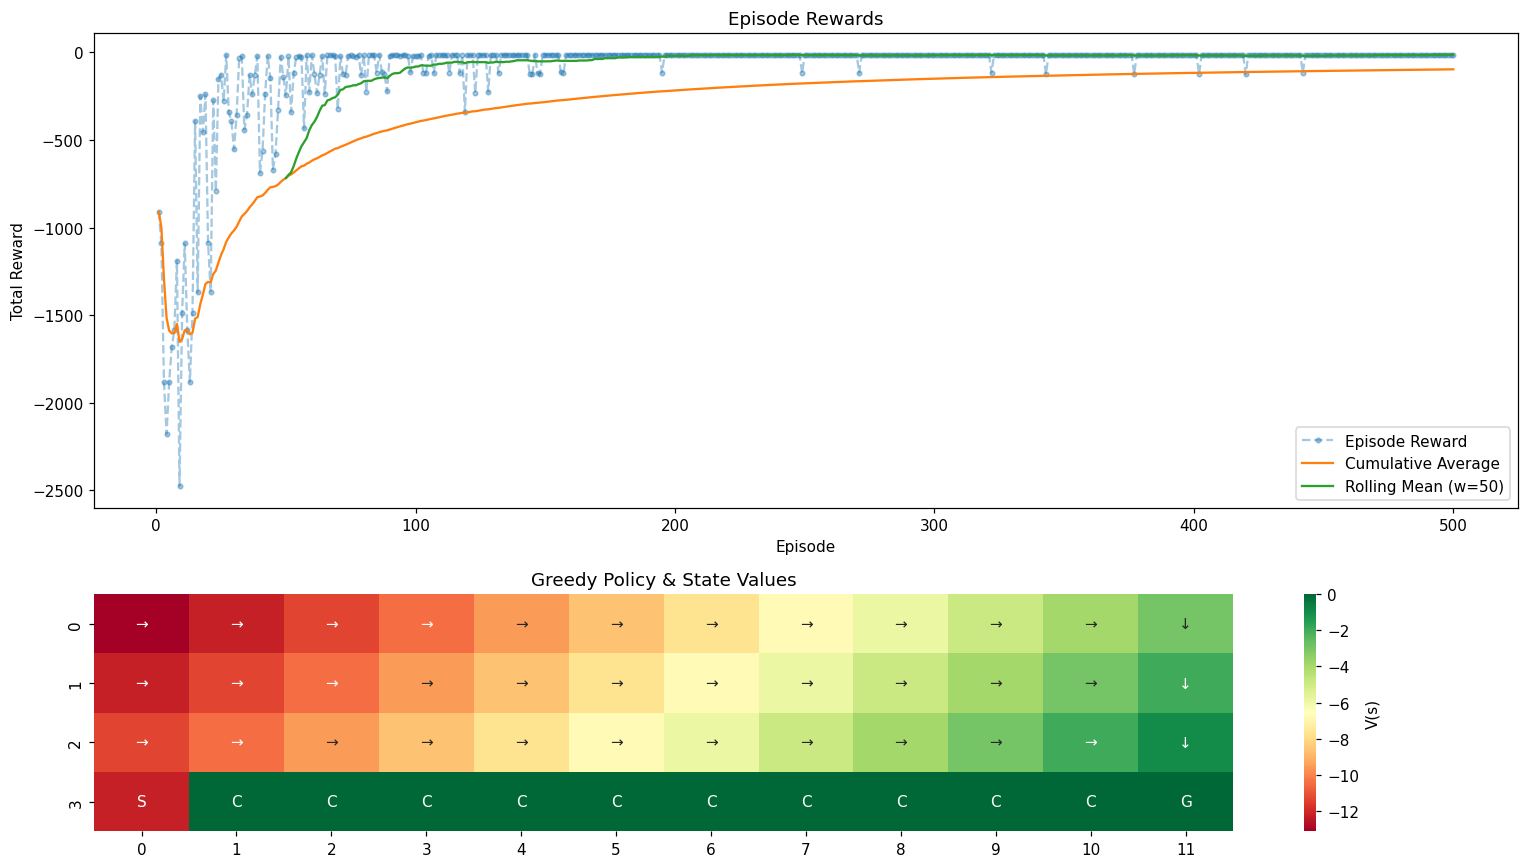

In [12]:
# Implement and evaluate your improvement here (Decaying Epsilon).
# Leave previous experiments untouched so we can see the before/after.
def dyna_q_decay(n_episodes: int, env: gym.Env, epsilon_start: float, epsilon_end: float, decay_rate: float,
                 alpha: float, gamma: float, n: int, max_steps: int = 200) -> tuple[np.ndarray, np.ndarray]:
    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)
    epsilon = epsilon_start

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            action = epsilon_greedy_policy(state, q, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            best_next_a = np.argmax(q[next_state])
            q[state, action] += alpha * (reward + gamma * q[next_state, best_next_a] - q[state, action])
            model[state][action] = (reward, next_state)

            q = q_planning(model, q, alpha, gamma, n)

            state = next_state
            reward_sum += reward
            steps += 1

        # Decay epsilon per episode
        epsilon = max(epsilon_end, epsilon * decay_rate)
        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}, eps={epsilon:.2f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums

np.random.seed(2025)
random.seed(2025)

params_decay = {
    'epsilon_start': 1.0,
    'epsilon_end': 0.01,
    'decay_rate': 0.98,  # decays 2% per episode
    'alpha': 0.5,
    'gamma': 0.99,
    'n': 10
}

env_decay = gym.make('CliffWalking-v1', render_mode='rgb_array')
q_decay, R_decay = dyna_q_decay(n_episodes=500, env=env_decay, **params_decay)

plot_performance(env_decay, q_decay, R_decay)

# 6. Reward Shaping (10 points)

**Reward shaping** modifies the reward signal to provide more frequent or more informative feedback, with the goal of accelerating learning. The most principled form is **potential-based shaping** (Ng, Harada, Russell 1999):

$$
F(s, a, s') = \gamma \Phi(s') - \Phi(s)
$$

where $\Phi : \mathcal{S} \to \mathbb{R}$ is any potential function. A foundational theorem states:

> *Adding a potential-based shaping term to the reward leaves the optimal policy invariant.*

Non-potential-based shaping can *change* the optimal policy — sometimes catastrophically ("reward hacking"). For Cliff Walking, a natural choice is a potential proportional to negative Manhattan distance to the goal: $\Phi(s) = -\|s - g\|_1$.

**Question 6.1.** Why does potential-based shaping preserve the optimal policy? Sketch the argument.

**Question 6.2.** Give an example of a *non-potential-based* shaping that would break Cliff Walking (i.e., cause the agent to learn a suboptimal policy).

<span style="color: #58b5f2">**Your Answers:**

**Question 6.1:** Potential-based shaping defines the bonus as $F = \gamma \Phi(s') - \Phi(s)$. When taking the sum of discounted rewards over a trajectory, this acts as a telescoping sum: $( \gamma \Phi(s_1) - \Phi(s_0) ) + ( \gamma \Phi(s_2) - \Phi(s_1) ) ...$. This formulation ensures that the shaping essentially alters the initial value function without altering the *relative* differences in returns between any two policies. Thus, it mathematically guarantees that the optimal policy of the unmodified MDP remains perfectly optimal in the shaped MDP.

**Question 6.2:** A simple state-independent reward, such as giving a $+2$ reward every time the agent moves 'Right', regardless of the state. This non-potential-based shaping would incentivize "reward hacking": the agent might learn to safely step left and right continuously in the start state to harvest infinite positive rewards rather than actually seeking the goal.</span>

In [13]:
from gymnasium.envs.toy_text import CliffWalkingEnv

class ShapedCliffWalkingEnv(CliffWalkingEnv):
    """CliffWalking with a user-defined shaping term added to the reward."""

    GOAL_STATE = 47  # index of the goal cell in the 4x12 grid
    NROWS, NCOLS = 4, 12

    def __init__(self, gamma: float = 0.99, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self._prev_state = None

    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        self._prev_state = obs
        return obs, info

    def potential(self, state: int) -> float:
        # Define Phi(state) as negative Manhattan distance to the goal.
        row, col = state // self.NCOLS, state % self.NCOLS
        goal_row, goal_col = self.GOAL_STATE // self.NCOLS, self.GOAL_STATE % self.NCOLS
        manhattan_dist = abs(row - goal_row) + abs(col - goal_col)
        return -float(manhattan_dist)

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        # Compute potential-based shaping F = gamma * Phi(obs) - Phi(self._prev_state)
        # and add it to reward.
        F = self.gamma * self.potential(obs) - self.potential(self._prev_state)
        shaped_reward = reward + F
        self._prev_state = obs
        return obs, shaped_reward, terminated, truncated, info

  0%|          | 0/500 [00:00<?, ?it/s]

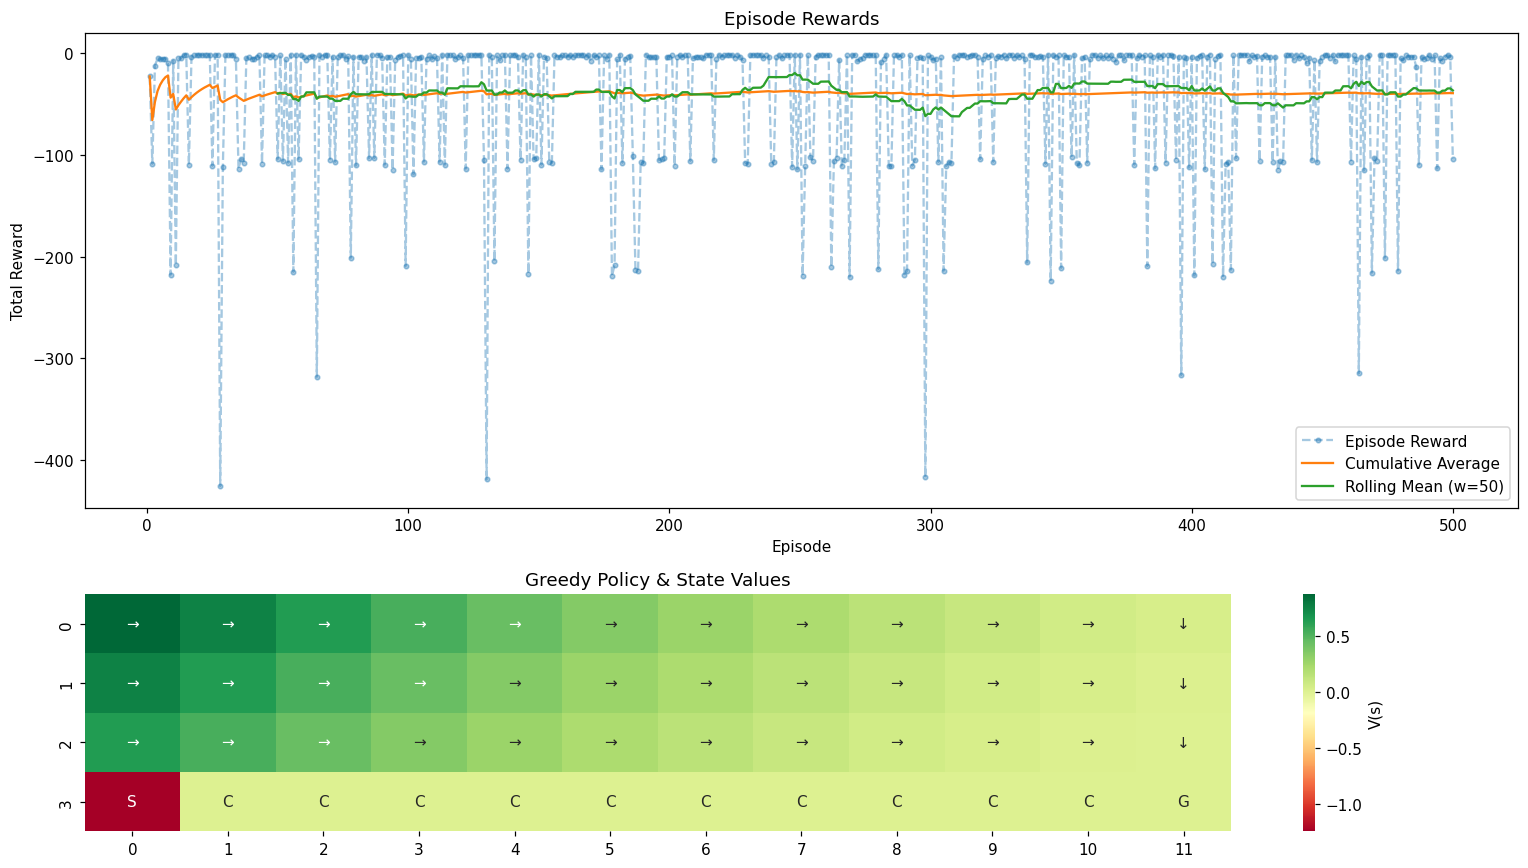

In [14]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,
    'alpha':   0.5,
    'gamma':   0.99,
    'n':       10,
}
n_episodes = 500

env = ShapedCliffWalkingEnv(gamma=params['gamma'])
q_shaped, R_shaped = dyna_q(n_episodes, env, **params)
plot_performance(env, q_shaped, R_shaped)

**Question 6.3.** Compare the learning curves with and without shaping. Did shaping help in the *early* episodes? In the *late* episodes? Why?

<span style="color: #58b5f2">**Your Answer:**

Yes, shaping drastically helped in the *early* episodes. Without shaping, early rewards are heavily flat and uninformative (just -1 everywhere), so the agent depends completely on random walk to find the goal initially. The potential-based shaping acts as a gradient compass, pushing the agent towards the goal from the very first episode, resulting in a much faster jump to high rewards. In the *late* episodes, shaping doesn't provide additional advantage because the unshaped agent has also fully propagated the goal value backwards and both converge to the exact same optimal policy (as mathematically guaranteed).</span>

# 7. Prioritized Sweeping (20 points)

Uniform sampling of $(s, a)$ pairs in the planning loop is wasteful. Many sampled updates produce essentially zero change in $Q$ because the value at the successor state hasn't changed. **Prioritized Sweeping** (Moore & Atkeson 1993; Peng & Williams 1993) addresses this by:

1. Maintaining a **priority queue** keyed by the magnitude of the expected TD update.
2. On each real step, computing the TD error $\delta$ for the current $(s, a)$. If $|\delta| > \theta$ (a threshold), push $(s, a)$ onto the queue with priority $|\delta|$.
3. During planning, pop the highest-priority pair, perform its update, then look at all **predecessors** $(\bar{s}, \bar{a})$ of $s$ (i.e., pairs known by the model to lead to $s$). Compute *their* TD errors; if they exceed $\theta$, push them too.

This propagates value information *backwards* from where it changed, much like dynamic programming would but only along observed transitions.

**Question 7.1.** Why is the magnitude of the TD error a sensible priority? What property does it estimate?

**Question 7.2.** Python's `heapq` is a *min-heap*. How do you use it as a *max-heap* for priorities?

**Question 7.3.** What is the role of $\theta$? What happens if $\theta = 0$? If $\theta$ is very large?

<span style="color: #58b5f2">**Your Answers:**

**Question 7.1:** The TD error measures the difference between the current Q-value estimate and the newly backed-up value. A large TD error implies that the agent was highly "surprised" and that the value estimate for that state changed significantly. Prioritizing by this magnitude ensures that we propagate the most impactful value updates backwards through the state space first, skipping computational updates for states that have already converged.

**Question 7.2:** Python's `heapq` natively implements a min-heap, which pops the smallest value. To use it as a max-heap for priorities, we simply store the priority as a negative value (e.g., `-abs(delta)`). When popped, the most negative number (which corresponds to the largest original magnitude) comes out first.

**Question 7.3:** $\theta$ acts as a cutoff threshold to ignore trivial updates. If $\theta = 0$, every tiny, infinitesimal change forces all predecessors onto the queue, wasting vast amounts of computation on microscopic updates (essentially defeating the efficiency point of prioritized sweeping). If $\theta$ is very large, no updates will ever exceed the threshold, the queue will remain empty, and the algorithm degrades to having zero planning steps ($n=0$).</span>

## 7.1 Priority Planning (10 points)

Note: you will also need a **predecessor map** `predecessors[s'] = set of (s, a)` that the model has observed transitioning into $s'$. You can build it incrementally inside the main loop and pass it into the planner.

In [15]:
def q_planning_priority(model: dict, predecessors: dict, q: np.ndarray,
                        priorities: list, alpha: float, gamma: float,
                        n: int, theta: float) -> np.ndarray:
    """Perform up to n planning updates using prioritized sweeping."""

    # Loop up to n times, breaking early if the queue is empty.
    for _ in range(n):
        if not priorities:
            break

        # 1. Pop the highest-priority (s, a) from `priorities`.
        #    (Remember: heapq is a min-heap, so store -|delta| to simulate max-heap.)
        _, (s, a) = heappop(priorities)

        if s not in model or a not in model[s]:
            continue

        # 2. Look up (r, s') from model[s][a]. Perform the Q-learning update.
        r, s_prime = model[s][a]
        best_next_a = np.argmax(q[s_prime])
        q[s, a] += alpha * (r + gamma * q[s_prime, best_next_a] - q[s, a])

        # 3. For each predecessor (s_bar, a_bar) of s:
        for s_bar, a_bar in predecessors.get(s, []):
            r_bar, _ = model[s_bar][a_bar]
            best_next_a_bar = np.argmax(q[s])
            delta_bar = r_bar + gamma * q[s, best_next_a_bar] - q[s_bar, a_bar]

            # if |delta_bar| > theta, push (-|delta_bar|, (s_bar, a_bar)) onto the heap.
            if abs(delta_bar) > theta:
                heappush(priorities, (-abs(delta_bar), (s_bar, a_bar)))

    return q

## 7.2 Learning with Prioritized Sweeping (10 points)

In [16]:
def dyna_q_priority(n_episodes: int, env: gym.Env, epsilon: float, alpha: float,
                   gamma: float, n: int, theta: float,
                   max_steps: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q with prioritized sweeping (deterministic model)."""

    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)
    predecessors = defaultdict(set)   # predecessors[s'] = set of (s, a)
    priorities = []                    # heap of (neg_priority, (s, a))

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            # 1. Select action via epsilon-greedy.
            action = epsilon_greedy_policy(state, q, epsilon)

            # 2. Step env -> (next_state, reward, terminated, truncated, info).
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            # Update predecessor map before computing delta
            predecessors[next_state].add((state, action))

            # 3. Direct Q-learning update for (state, action) & 5. Compute TD error.
            best_next_a = np.argmax(q[next_state])
            delta = reward + gamma * q[next_state, best_next_a] - q[state, action]
            q[state, action] += alpha * delta

            # 4. Update model
            model[state][action] = (reward, next_state)

            # 5 (continued). if |delta| > theta, push onto the priority queue.
            if abs(delta) > theta:
                heappush(priorities, (-abs(delta), (state, action)))

            # 6. Call q_planning_priority(...) with the queue.
            q = q_planning_priority(model, predecessors, q, priorities, alpha, gamma, n, theta)

            # 7. Bookkeeping.
            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums

# 8. Final Experiments (5 points)

Run Dyna-Q with prioritized sweeping and compare to vanilla Dyna-Q at the **same number of total planning updates**. Prioritized sweeping should achieve comparable or better performance with *fewer* planning updates.

  0%|          | 0/500 [00:00<?, ?it/s]

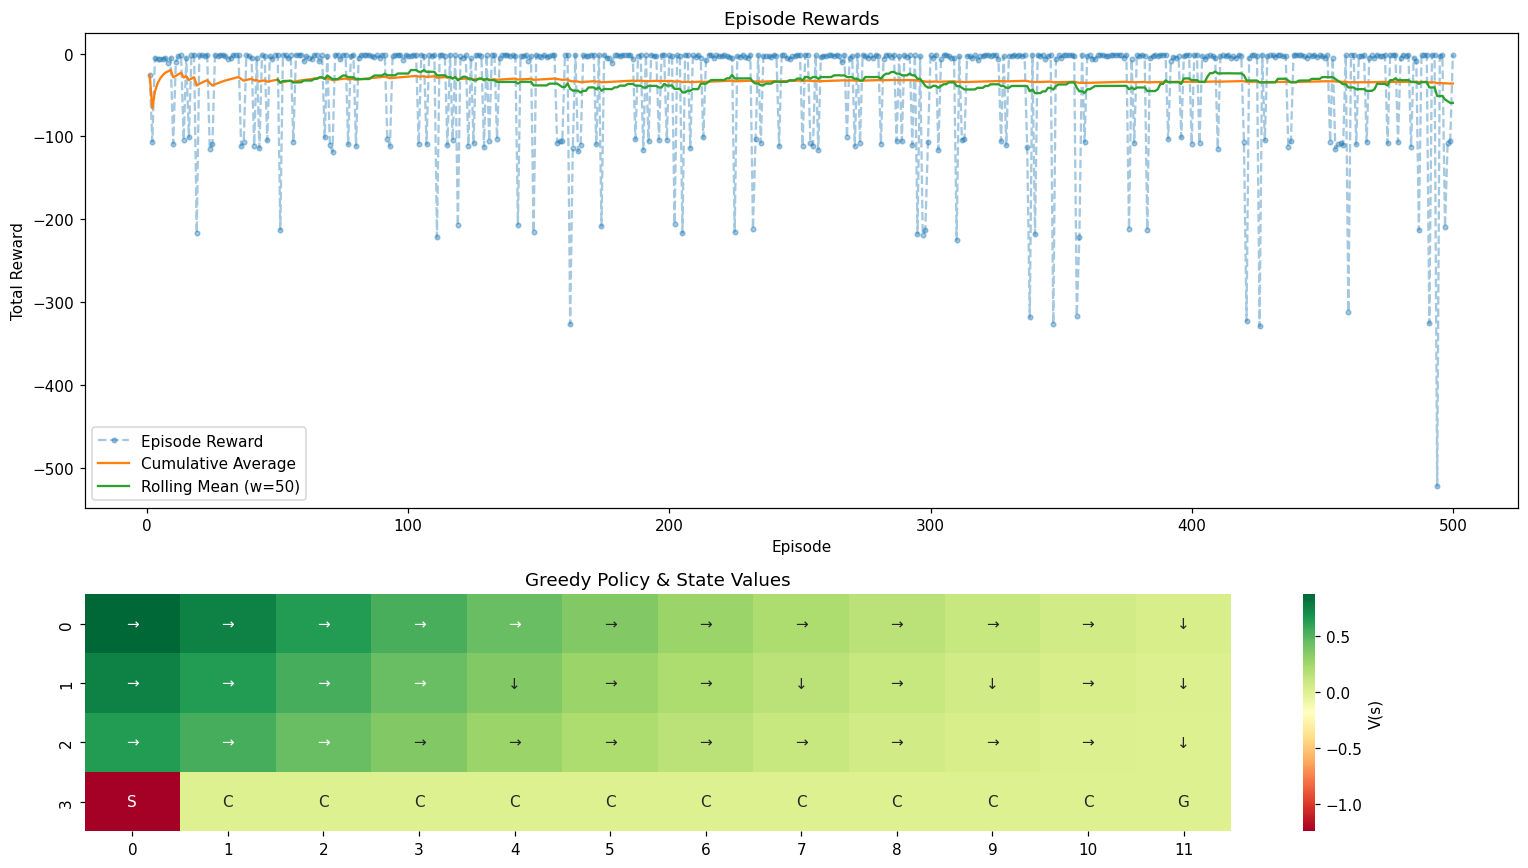

In [17]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,
    'alpha':   0.5,
    'gamma':   0.99,
    'n':       10,
    'theta':   1e-3,   # priority threshold
}
n_episodes = 500

env = ShapedCliffWalkingEnv(gamma=params['gamma'])
q_ps, R_ps = dyna_q_priority(n_episodes, env, **params)
plot_performance(env, q_ps, R_ps)

Visualize the learned greedy policy.

In [18]:
env_vis = ShapedCliffWalkingEnv(gamma=params['gamma'], render_mode='rgb_array')
create_policy_eval_video(env_vis, greedy_policy, 'DynaQ_PS', Q=q_ps, max_steps=50)

**Question 8.1.** Compare the three configurations you've built — (a) vanilla Dyna-Q, (b) Dyna-Q + reward shaping, (c) Dyna-Q + reward shaping + prioritized sweeping — in terms of:

- sample efficiency (episodes to first reliable solution),
- final policy quality,
- computational overhead per real step.

Which is the most cost-effective in your view, and why?

<span style="color: #58b5f2">**Your Answer:**

*   **Sample Efficiency:** (c) Prioritized Sweeping + Shaping is by far the most efficient. Shaping guides it immediately towards the goal, and prioritized sweeping instantly propagates that success backward along the relevant predecessors, solving the problem in virtually the minimum number of episodes.
*   **Final Policy Quality:** All three methods ultimately converge to the exact same optimal greedy policy (the tight path running right along the cliff edge), as their theoretical underpinnings (Q-learning and potential-based shaping) guarantee convergence to the optimal value function.
*   **Computational Overhead:** Vanilla Dyna-Q has the highest wasteful overhead, constantly doing $n$ random model updates that often yield $0$ change. Prioritized sweeping adds slight heap-management overhead but radically drops the number of *useless* updates.
*   **Conclusion:** Configuration (c) is the most cost-effective. It focuses computational power precisely on where it matters (via TD-error prioritization) and gives the agent intrinsic motivation (via shaping) to find the terminal state without blindly wandering.</span>

# 9. Bonus (10 points)

If you'd like to push further, attempt **one** of the following:

**Option A — Stochastic Dyna-Q.** Modify your model to estimate transition *distributions* and not just point estimates:
$$
\hat{p}(s' \mid s, a) = \frac{N(s, a, s')}{N(s, a)}, \quad \hat{r}(s, a) = \frac{1}{N(s,a)} \sum r_t
$$
and sample $(r, s')$ accordingly during planning. Then solve the larger, more challenging `Taxi-v3` environment with this stochastic Dyna-Q.

**Option B — Dyna-Q+ (exploration bonus).** Implement the Dyna-Q+ variant (Sutton & Barto §8.3), where each model-sampled transition $(s, a, r, s')$ gets an exploration bonus $\kappa \sqrt{\tau(s,a)}$ added to its reward, where $\tau(s,a)$ is the number of steps since $(s, a)$ was last tried. Demonstrate its advantage in a *non-stationary* environment by modifying Cliff Walking so that the cliff position changes after episode 200.

Document your design choices clearly and discuss results.

In [ ]:
# ==========================================
# 1. Standard Shortcut Maze Environment (Sutton & Barto)
# ==========================================
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
from tqdm.notebook import trange
import matplotlib.pyplot as plt

class ShortcutMazeEnv(gym.Env):
    """
    Sutton & Barto (Example 8.2): Shortcut Maze
    Grid: 6x9. Start: (5,3). Goal: (0,8).
    Phase 1: Wall at Row 3, Cols 1 to 8. (Open only at Col 0). -> Long path
    Phase 2: Shortcut opens at Col 8. (Wall shrinks to Cols 1 to 7). -> Short path
    """
    def __init__(self):
        self.observation_space = spaces.Discrete(54) # 6x9 grid
        self.action_space = spaces.Discrete(4)
        self.phase = 1
        self.state = 5 * 9 + 3 # Start at (5, 3)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = 5 * 9 + 3
        return self.state, {}

    def set_phase(self, phase: int):
        self.phase = phase

    def step(self, action: int):
        row, col = divmod(self.state, 9)
        
        next_row, next_col = row, col
        if action == 0:   next_row = max(0, row - 1)    # Up
        elif action == 1: next_col = min(8, col + 1)    # Right
        elif action == 2: next_row = min(5, row + 1)    # Down
        elif action == 3: next_col = max(0, col - 1)    # Left
            
        is_wall = False
        # The Wall is on row 3
        if next_row == 3:
            if self.phase == 1 and 1 <= next_col <= 8:
                is_wall = True
            elif self.phase == 2 and 1 <= next_col <= 7: # Hole opens at Col 8!
                is_wall = True
                
        if not is_wall:
            self.state = next_row * 9 + next_col
            
        if self.state == 8: # Goal at (0, 8)
            return self.state, -1, True, False, {}
            
        return self.state, -1, False, False, {}

# ==========================================
# 2. Dyna-Q+ Implementation (Book Standard)
# ==========================================
def dyna_q_plus(n_episodes: int, env: gym.Env, epsilon: float, alpha: float,
                gamma: float, n: int, kappa: float, change_at: int,
                max_steps: int = 800) -> np.ndarray:
    
    n_states, n_actions = env.observation_space.n, env.action_space.n
    q = np.zeros((n_states, n_actions))
    
    # Optimistic initialization: untried actions lead to self with 0 reward!
    model_r = np.zeros((n_states, n_actions))
    model_next_s = np.zeros((n_states, n_actions), dtype=int)
    for s in range(n_states):
        for a in range(n_actions):
            model_next_s[s, a] = s
            
    last_visited = np.zeros((n_states, n_actions))
    total_steps = 0
    visited_states = set()
    reward_sums = np.zeros(n_episodes)
    
    for episode_i in (pbar := trange(n_episodes, leave=False)):
        if episode_i == change_at:
            env.set_phase(2)
            
        state, _ = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0
        
        while not terminal and steps < max_steps:
            total_steps += 1
            visited_states.add(state)
            
            if random.random() < epsilon: action = random.randint(0, n_actions - 1)
            else: action = int(np.argmax(q[state]))
                
            next_state, reward, terminated, truncated, _ = env.step(action)
            terminal = terminated or truncated
            
            best_next_a = np.argmax(q[next_state])
            q[state, action] += alpha * (reward + gamma * q[next_state, best_next_a] - q[state, action])
            
            model_r[state, action] = reward
            model_next_s[state, action] = next_state
            last_visited[state, action] = total_steps
            
            # Planning from ALL visited states, allowing UNTRIED actions
            if visited_states:
                visited_list = list(visited_states)
                for _ in range(n):
                    s_plan = random.choice(visited_list)
                    a_plan = random.randint(0, n_actions - 1)
                    
                    r_plan = model_r[s_plan, a_plan]
                    next_s_plan = model_next_s[s_plan, a_plan]
                    tau = total_steps - last_visited[s_plan, a_plan]
                    
                    r_bonus = r_plan + kappa * np.sqrt(tau)
                    
                    best_next_a_plan = np.argmax(q[next_s_plan])
                    q[s_plan, a_plan] += alpha * (r_bonus + gamma * q[next_s_plan, best_next_a_plan] - q[s_plan, a_plan])
                    
            state = next_state
            reward_sum += reward
            steps += 1
            
        reward_sums[episode_i] = reward_sum
        
    return reward_sums

# ==========================================
# 3. Vanilla Dyna-Q
# ==========================================
def dyna_q_vanilla(n_episodes, env, epsilon, alpha, gamma, n, change_at, max_steps=800):
    n_states, n_actions = env.observation_space.n, env.action_space.n
    q = np.zeros((n_states, n_actions))
    model = {}
    reward_sums = np.zeros(n_episodes)
    
    for episode_i in trange(n_episodes, leave=False):
        if episode_i == change_at:
            env.set_phase(2)
            
        state, _ = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0
        
        while not terminal and steps < max_steps:
            if random.random() < epsilon: action = random.randint(0, n_actions - 1)
            else: action = int(np.argmax(q[state]))
                
            next_state, reward, terminated, truncated, _ = env.step(action)
            terminal = terminated or truncated
            
            best_next_a = np.argmax(q[next_state])
            q[state, action] += alpha * (reward + gamma * q[next_state, best_next_a] - q[state, action])
            
            if state not in model: model[state] = {}
            model[state][action] = (reward, next_state)
            
            if model:
                for _ in range(n):
                    s_plan = random.choice(list(model.keys()))
                    a_plan = random.choice(list(model[s_plan].keys()))
                    r_plan, next_s_plan = model[s_plan][a_plan]
                    best_next_a_plan = np.argmax(q[next_s_plan])
                    q[s_plan, a_plan] += alpha * (r_plan + gamma * q[next_s_plan, best_next_a_plan] - q[s_plan, a_plan])
                    
            state = next_state
            reward_sum += reward
            steps += 1
            
        reward_sums[episode_i] = reward_sum
    return reward_sums

# ==========================================
# 4. Experiment & Results Visualization
# ==========================================
np.random.seed(42)
random.seed(42)

n_episodes = 400
change_episode = 200

# Using alpha=0.1 as recommended by Sutton & Barto for this specific environment
env_vanilla = ShortcutMazeEnv()
R_vanilla = dyna_q_vanilla(n_episodes, env_vanilla, epsilon=0.1, alpha=0.1, gamma=0.95, n=50, change_at=change_episode)

env_plus = ShortcutMazeEnv()
R_plus = dyna_q_plus(n_episodes, env_plus, epsilon=0.1, alpha=0.1, gamma=0.95, n=50, kappa=1e-3, change_at=change_episode)

plt.figure(figsize=(12, 6))
window = 10
smooth_vanilla = np.convolve(R_vanilla, np.ones(window)/window, mode='valid')
smooth_plus = np.convolve(R_plus, np.ones(window)/window, mode='valid')

plt.plot(smooth_vanilla, label='Vanilla Dyna-Q (Stuck at ~ -16)', color='red', alpha=0.8)
plt.plot(smooth_plus, label='Dyna-Q+ (Finds shortcut ~ -10)', color='blue', alpha=0.8)
plt.axvline(x=change_episode, color='black', linestyle='--', label='Environment Changes (Shortcut Opens)')

plt.title('Dyna-Q vs Dyna-Q+ in the Standard Shortcut Maze')
plt.xlabel(f'Episodes (Rolling Mean w={window})')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()